In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import pyreadr
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve
from ipfn import ipfn

In [2]:
RUTA_CENSO_ZONAL = "../data/parquet/Cartografía_censo2024_R13_Zonal.parquet"
RUTA_CASEN = "../data/rds/casen_rm.rds"
RUTA_EPF_PERSONAS = "../data/epf/base-personas-ix-epf-stata.dta"
RUTA_EPF_CANTIDADES = "../data/epf/base-cantidades-ix-epf-stata.dta"

SEED = 123

In [3]:
CODIGO_CCIF = "02.1.2.01.01"

In [4]:
personas = pd.read_stata(RUTA_EPF_PERSONAS, convert_categoricals=False)
cantidades = pd.read_stata(
    RUTA_EPF_CANTIDADES, convert_categoricals=False,
    columns=["folio", "n_linea", "ccif", "macrozona", "gasto"],
)

valores_invalidos = [-99, -88, -77]
epf = personas[
    (personas["macrozona"] == 2)
    & (~personas["edad"].isin(valores_invalidos))
    & (~personas["edue"].isin(valores_invalidos))
    & (personas["ing_disp_hog_hd_ai"] >= 0)
].copy()

epf["ing_pc"] = epf["ing_disp_hog_hd_ai"] / epf["npersonas"]

# id_persona: forzamos n_linea a entero ANTES de convertir a texto, en ambas bases
epf["id_persona"] = epf["folio"].astype(str) + "_" + epf["n_linea"].astype("Int64").astype(str)
cantidades["id_persona"] = cantidades["folio"].astype(str) + "_" + cantidades["n_linea"].astype("Int64").astype(str)

In [11]:
RUTA_CSV_EPF = '../data/epf/ccif-ix-epf-(formato-csv).csv'

ccif = pd.read_csv(RUTA_CSV_EPF,
                  sep=None, engine="python", encoding="utf-8-sig")




In [7]:
CODIGO_CCIF = "02.1.2.01.01" # Parámetro a modificar

In [10]:
ccif[ccif['ccif'] == CODIGO_CCIF]

,d,g,c,sc,p,ccif,glosa_ccif
409,2,1,2,1,1,02.1.2.01.01,VINO DE UVAS


In [12]:
gasto_bien = cantidades[(cantidades["ccif"] == CODIGO_CCIF) & (cantidades["macrozona"] == 2)]
gasto_por_persona = gasto_bien.groupby("id_persona")["gasto"].sum().reset_index()
gasto_por_persona.columns = ["id_persona", "gasto_bien"]

epf = epf.merge(gasto_por_persona, on="id_persona", how="left")
epf["gasto_bien"] = epf["gasto_bien"].fillna(0)
epf["incurre_gasto"] = (epf["gasto_bien"] > 0).astype(int)

print(f"Personas que incurren en el gasto: {epf['incurre_gasto'].sum()} / {len(epf)} "
      f"({100 * epf['incurre_gasto'].mean():.1f}%)")

Personas que incurren en el gasto: 939 / 17340 (5.4%)


In [14]:
# Recodificar para calzar con CASEN

epf["grupo_escolaridad"] = pd.cut(
    epf["edue"], bins=[-np.inf, 12, 14, 16, np.inf],
    labels=["Escolar", "Tecnico", "Universitaria", "Postgrado"],
)
epf["rango_edad"] = pd.cut(
    epf["edad"], bins=[-1, 29, 44, 64, np.inf],  # -1 (no 0) para que edad=0 (recién nacidos) quede incluido
    labels=["jovenes", "adultos_jovenes", "adultos", "adultos_mayores"],
)
epf["sexo_lbl"] = epf["sexo"].map({1: "Hombre", 2: "Mujer"})

epf.groupby("incurre_gasto")[["edad", "ing_pc"]].mean().round(0)


,edad,ing_pc
incurre_gasto,,
0,36.0,608335.0
1,52.0,1013305.0


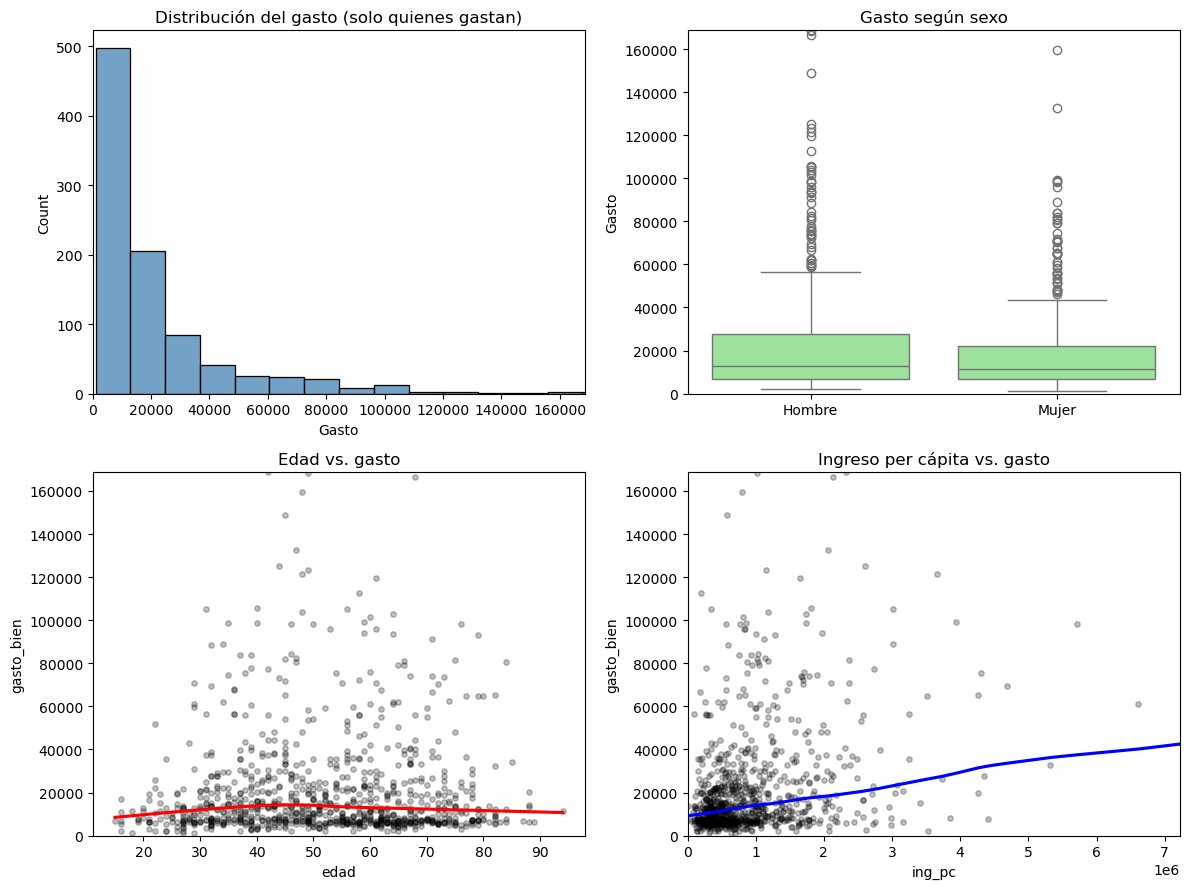

In [15]:
spenders = epf[epf["gasto_bien"] > 0]
tope_grafico = spenders["gasto_bien"].quantile(0.99)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1) Distribución del gasto, solo entre quienes gastan
sns.histplot(spenders["gasto_bien"], bins=30, color="steelblue", ax=axes[0, 0])
axes[0, 0].set_xlim(0, tope_grafico)
axes[0, 0].set_title("Distribución del gasto (solo quienes gastan)")
axes[0, 0].set_xlabel("Gasto")

# 2) Gasto según sexo
sns.boxplot(data=spenders, x="sexo_lbl", y="gasto_bien", ax=axes[0, 1], color="lightgreen")
axes[0, 1].set_ylim(0, tope_grafico)
axes[0, 1].set_title("Gasto según sexo")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Gasto")

# 3) Edad vs. gasto, con curva de tendencia suavizada (lowess)
sns.regplot(
    data=spenders, x="edad", y="gasto_bien", ax=axes[1, 0],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "red"},
)
axes[1, 0].set_ylim(0, tope_grafico)
axes[1, 0].set_title("Edad vs. gasto")

# 4) Ingreso vs. gasto, con curva de tendencia suavizada
sns.regplot(
    data=spenders, x="ing_pc", y="gasto_bien", ax=axes[1, 1],
    scatter_kws={"alpha": 0.25, "s": 15, "color": "black"},
    lowess=True, line_kws={"color": "blue"},
)
axes[1, 1].set_ylim(0, tope_grafico)
axes[1, 1].set_xlim(0, spenders["ing_pc"].quantile(0.99))
axes[1, 1].set_title("Ingreso per cápita vs. gasto")

plt.tight_layout()
plt.show()

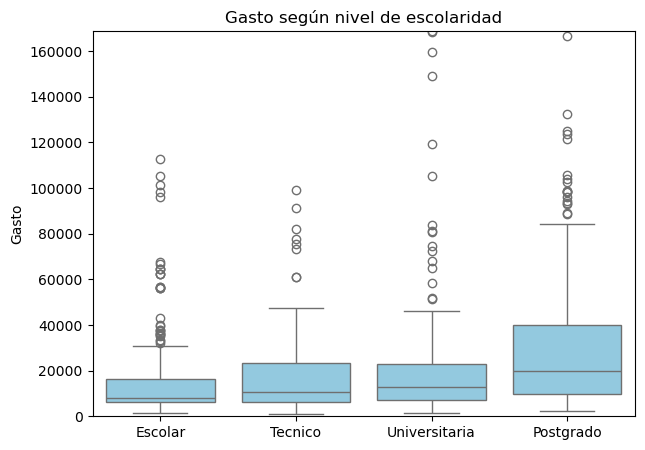

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
orden_escolaridad = ["Escolar", "Tecnico", "Universitaria", "Postgrado"]
sns.boxplot(data=spenders, x="grupo_escolaridad", y="gasto_bien", order=orden_escolaridad, ax=ax, color="skyblue")
ax.set_ylim(0, tope_grafico)
ax.set_title("Gasto según nivel de escolaridad")
ax.set_xlabel("")
ax.set_ylabel("Gasto")
plt.show()

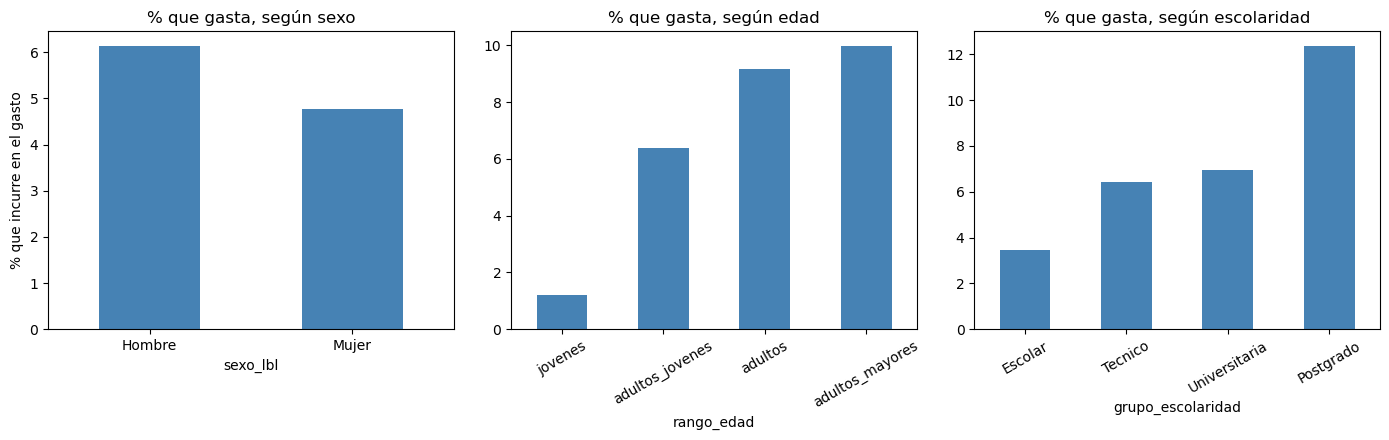

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

epf.groupby("sexo_lbl")["incurre_gasto"].mean().mul(100).plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("% que gasta, según sexo")
axes[0].set_ylabel("% que incurre en el gasto")
axes[0].tick_params(axis="x", rotation=0)

epf.groupby("rango_edad", observed=True)["incurre_gasto"].mean().mul(100).plot.bar(ax=axes[1], color="steelblue")
axes[1].set_title("% que gasta, según edad")
axes[1].tick_params(axis="x", rotation=30)

epf.groupby("grupo_escolaridad", observed=True)["incurre_gasto"].mean().reindex(orden_escolaridad).mul(100).plot.bar(ax=axes[2], color="steelblue")
axes[2].set_title("% que gasta, según escolaridad")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [18]:
modelo_data = epf.dropna(subset=["edad", "grupo_escolaridad", "sexo_lbl", "ing_pc"]).copy()

modelo_logit = smf.logit(
    "incurre_gasto ~ C(sexo_lbl) + edad + C(grupo_escolaridad) + ing_pc",
    data=modelo_data,
).fit(disp=0)

print(modelo_logit.summary())

modelo_data["prob_predicha"] = modelo_logit.predict(modelo_data)
auc = roc_auc_score(modelo_data["incurre_gasto"], modelo_data["prob_predicha"])
print(f"\nAUC: {auc:.3f}")

                           Logit Regression Results                           
Dep. Variable:          incurre_gasto   No. Observations:                17340
Model:                          Logit   Df Residuals:                    17333
Method:                           MLE   Df Model:                            6
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                  0.1066
Time:                        10:09:20   Log-Likelihood:                -3262.1
converged:                       True   LL-Null:                       -3651.2
Covariance Type:            nonrobust   LLR p-value:                8.042e-165
                                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------
Intercept                                -4.8436      0.115    -42.228      0.000      -5.068      -4.619
C(sexo_lbl)[T.Mujer]                     -0.3484  

In [19]:
tabla_gasto = epf[epf["gasto_bien"] > 0].copy()
tabla_gasto["log_gasto_bien"] = np.log(tabla_gasto["gasto_bien"] + 1)

q_ing = tabla_gasto["ing_pc"].quantile([0.01, 0.99])
q_gasto = tabla_gasto["gasto_bien"].quantile([0.01, 0.99])
tabla_gasto = tabla_gasto[
    tabla_gasto["ing_pc"].between(q_ing.iloc[0], q_ing.iloc[1])
    & tabla_gasto["gasto_bien"].between(q_gasto.iloc[0], q_gasto.iloc[1])
]

print(f"Personas para el modelo de monto: {len(tabla_gasto)}")

modelo_lineal = smf.ols(
    "log_gasto_bien ~ C(grupo_escolaridad) + ing_pc + C(rango_edad) + C(sexo_lbl)",
    data=tabla_gasto,
).fit()

print(modelo_lineal.summary())

Personas para el modelo de monto: 902
                            OLS Regression Results                            
Dep. Variable:         log_gasto_bien   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     20.07
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           4.86e-28
Time:                        10:13:54   Log-Likelihood:                -1085.2
No. Observations:                 902   AIC:                             2188.
Df Residuals:                     893   BIC:                             2232.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [23]:
def calcular_demanda(df, prob_col="prob_predicha"):
    """Aplica el modelo lineal (monto condicional) y combina con la
    probabilidad de incidencia ya calculada en `prob_col`.
    """
    df = df.copy()
    df["log_gasto_pred"] = modelo_lineal.predict(df)
    df["gasto_pred"] = np.exp(df["log_gasto_pred"]) - 1

    # winsorización: acotamos montos extremos al percentil 99.9 de la EPF
    tope = tabla_gasto["gasto_bien"].quantile(0.999)
    df["gasto_pred_wins"] = df["gasto_pred"].clip(upper=tope)

    df["demanda_ind"] = df[prob_col] * df["gasto_pred_wins"]
    return df

In [21]:
casen_raw = pyreadr.read_r(RUTA_CASEN)
casen_raw = casen_raw[list(casen_raw.keys())[0]]

vars_casen = ["estrato", "esc", "e6a", "edad", "sexo",
              "v13", "v13_propia", "v13_arrendada", "v13_cedida", "ypc"]
casen = casen_raw[vars_casen].copy()
del casen_raw

casen["comuna"] = (casen["estrato"] // 100).astype("Int64")
casen = casen.drop(columns="estrato")

# imputación de esc en base a e6a, idéntica a la de clases
falta_esc = casen["esc"].isna()
modelo_esc = LinearRegression().fit(
    casen.loc[~falta_esc, ["e6a"]], casen.loc[~falta_esc, "esc"]
)
pred = modelo_esc.predict(casen.loc[falta_esc, ["e6a"]])
casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 29)

casen = casen[~casen["ypc"].isna()].reset_index(drop=True)
print(f"Personas CASEN disponibles: {len(casen)}")

Personas CASEN disponibles: 38607


In [24]:
# --- Recodificación con los cortes del modelo EPF (sección 2), no los del censo ---
casen["grupo_escolaridad"] = pd.cut(
    casen["esc"], bins=[-np.inf, 12, 14, 16, np.inf],
    labels=["Escolar", "Tecnico", "Universitaria", "Postgrado"],
)
casen["rango_edad"] = pd.cut(
    casen["edad"], bins=[-1, 29, 44, 64, np.inf],  # -1 (no 0) para que edad=0 (recién nacidos) quede incluido
    labels=["jovenes", "adultos_jovenes", "adultos", "adultos_mayores"],
)
casen["sexo_lbl"] = casen["sexo"].map({1: "Hombre", 2: "Mujer"})
casen["ing_pc"] = casen["ypc"]

casen["prob_predicha"] = modelo_logit.predict(casen)
casen = calcular_demanda(casen)

print(casen[["grupo_escolaridad", "rango_edad", "sexo_lbl", "prob_predicha", "demanda_ind"]].head())
print(f"\nDemanda individual promedio en la CASEN: {casen['demanda_ind'].mean():.1f}")

  grupo_escolaridad rango_edad sexo_lbl  prob_predicha  demanda_ind
0           Escolar    adultos    Mujer       0.039755   405.906319
1           Escolar    jovenes    Mujer       0.016368   121.098221
2         Postgrado    jovenes    Mujer       0.049599   577.871627
3           Escolar    jovenes    Mujer       0.011992    88.724030
4           Escolar    adultos   Hombre       0.059192   666.657675

Demanda individual promedio en la CASEN: 898.8


In [26]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL).rename_geometry("geometry")
es_gran_santiago = (censo_zonal["PROVINCIA"] == "SANTIAGO") | (
    censo_zonal["COMUNA"].isin(["PUENTE ALTO", "SAN BERNARDO"])
)
censo_zonal = censo_zonal[es_gran_santiago].reset_index(drop=True)

censo_comunal = gpd.read_parquet(
    RUTA_CENSO_ZONAL.replace("_Zonal", "_Comunal")
).rename_geometry("geometry")
censo_comunal = censo_comunal[
    (censo_comunal["PROVINCIA"] == "SANTIAGO") | (censo_comunal["COMUNA"].isin(["PUENTE ALTO", "SAN BERNARDO"]))
].reset_index(drop=True)

comunas_gs = censo_zonal["CUT"].unique()
casen = casen[casen["comuna"].isin(comunas_gs)].reset_index(drop=True)

print(f"Zonas censales en Gran Santiago: {len(censo_zonal)}")
print(f"Personas CASEN en Gran Santiago: {len(casen)}")

Zonas censales en Gran Santiago: 1642
Personas CASEN en Gran Santiago: 32141


In [27]:
# --- Recodificación a las categorías censales (para los constraints del IPF) ---
COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5", "edad_6_13": "n_edad_6_13", "edad_14_17": "n_edad_14_17",
    "edad_18_24": "n_edad_18_24", "edad_25_44": "n_edad_25_44",
    "edad_45_59": "n_edad_45_59", "edad_60_mas": "n_edad_60_mas",
}
COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]
COLS_TENENCIA = {
    "ten_propia_pagada": "n_tenencia_propia_pagada",
    "ten_propia_pagandose": "n_tenencia_propia_pagandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

casen["sexo_cat"] = casen["sexo"].map({1: "hombre", 2: "mujer"})
casen["edad_cat"] = pd.cut(
    casen["edad"], bins=[0, 6, 14, 18, 25, 45, 60, np.inf],
    labels=list(COLS_EDAD.keys()), right=False, include_lowest=True,
).astype(str)
casen["educ_cat"] = pd.cut(
    casen["esc"], bins=[-1, 0, 8, 12, np.inf], labels=COLS_EDUC,
).astype(str)

condiciones = [
    (casen["v13"] == 1) & (casen["v13_propia"] == 1),
    (casen["v13"] == 1) & (casen["v13_propia"] == 2),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 5),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 6),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 7),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 8),
]
categorias_tenencia = [
    "ten_propia_pagada", "ten_propia_pagandose",
    "ten_arrendada_contrato", "ten_arrendada_sin_contrato",
    "ten_cedida_trabajo", "ten_cedida_familiar",
]
casen["tenencia_cat"] = np.select(condiciones, categorias_tenencia, default="ten_otro")

# --- Tabla de constraints por zona (idéntica a clases) ---
ZONA_ID = "OBJECTID"
constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()
for nombre, col in {**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]
constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = censo_zonal["n_cine_primaria"] + censo_zonal["n_cine_especial_diferencial"]
constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]
personas_por_hogar = np.where(censo_zonal["n_hog"] > 0, censo_zonal["n_per"] / censo_zonal["n_hog"], 0)
for nombre, col in COLS_TENENCIA.items():
    constraints[nombre] = censo_zonal[col] * personas_por_hogar

CATEGORIAS = {
    "sexo_cat": list(COLS_SEXO.keys()),
    "edad_cat": list(COLS_EDAD.keys()),
    "educ_cat": COLS_EDUC,
    "tenencia_cat": list(COLS_TENENCIA.keys()),
}
constraints = constraints.set_index(ZONA_ID)

In [28]:
def pesos_por_persona(seed, codigos, celda_a_personas):
    dims = [[i] for i in range(len(codigos["objetivos"]))]
    IPF = ipfn.ipfn(seed.copy(), codigos["objetivos"], dims, convergence_rate=1e-6, max_iteration=50)
    tabla_reponderada = IPF.iteration()
    peso_celda = tabla_reponderada[codigos["indices"]]
    return peso_celda / celda_a_personas


def integerise_trs(pesos, rng):
    parte_entera = np.floor(pesos).astype(int)
    parte_fraccionaria = pesos - parte_entera
    idx = np.arange(len(pesos))
    replicados = np.repeat(idx, parte_entera)
    n_total = int(round(pesos.sum()))
    n_faltante = n_total - parte_entera.sum()
    if n_faltante > 0 and parte_fraccionaria.sum() > 0:
        probs = parte_fraccionaria / parte_fraccionaria.sum()
        extra = rng.choice(idx, size=n_faltante, replace=True, p=probs)
        replicados = np.concatenate([replicados, extra])
    return replicados

In [29]:
import contextlib
import io
import warnings

rng = np.random.default_rng(SEED)
VARS_CONSTRAINT = list(CATEGORIAS.keys())

resultados_zona = []
buffer_salida = io.StringIO()
with contextlib.redirect_stdout(buffer_salida), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for comuna_cut, cons_comuna in constraints.groupby("CUT"):
        muestra_comuna = casen[casen["comuna"] == comuna_cut]
        if len(muestra_comuna) == 0:
            continue

        indices = {
            var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes
            for var in VARS_CONSTRAINT
        }
        forma = tuple(len(CATEGORIAS[var]) for var in VARS_CONSTRAINT)
        seed_tabla = np.zeros(forma)
        indices_tupla = tuple(indices[var] for var in VARS_CONSTRAINT)
        np.add.at(seed_tabla, indices_tupla, 1)
        celda_a_personas = seed_tabla[indices_tupla]

        demanda_ind_comuna = muestra_comuna["demanda_ind"].to_numpy()
        ypc_comuna = muestra_comuna["ypc"].to_numpy()

        for zona_id, fila in cons_comuna.iterrows():
            if fila["n_per"] == 0:
                continue

            objetivos = [
                np.array([fila[cat] for cat in CATEGORIAS[var]], dtype=float)
                for var in VARS_CONSTRAINT
            ]
            pesos = pesos_por_persona(seed_tabla, {"objetivos": objetivos, "indices": indices_tupla}, celda_a_personas)
            sinteticos_idx = integerise_trs(pesos, rng)

            demanda_sintetica = demanda_ind_comuna[sinteticos_idx]

            resultados_zona.append({
                "zona_id": zona_id,
                "CUT": comuna_cut,
                "n_sintetico": len(sinteticos_idx),
                "n_censo": fila["n_per"],
                "demanda_total": demanda_sintetica.sum(),
                "demanda_percap": demanda_sintetica.mean() if len(demanda_sintetica) else np.nan,
            })

resultados_zona = pd.DataFrame(resultados_zona).set_index("zona_id")
print(f"Zonas simuladas: {len(resultados_zona)}")
resultados_zona.head()

Zonas simuladas: 1640


,CUT,n_sintetico,n_censo,demanda_total,demanda_percap
zona_id,,,,,
4309,13101,3918,3923.0,2.645925e+06,675.325371
4310,13101,6245,6250.0,3.746685e+06,599.949639
4311,13101,4038,4038.0,3.056907e+06,757.034868
4312,13101,3050,3050.0,2.112300e+06,692.557486
4313,13101,5597,5599.0,4.521476e+06,807.839120


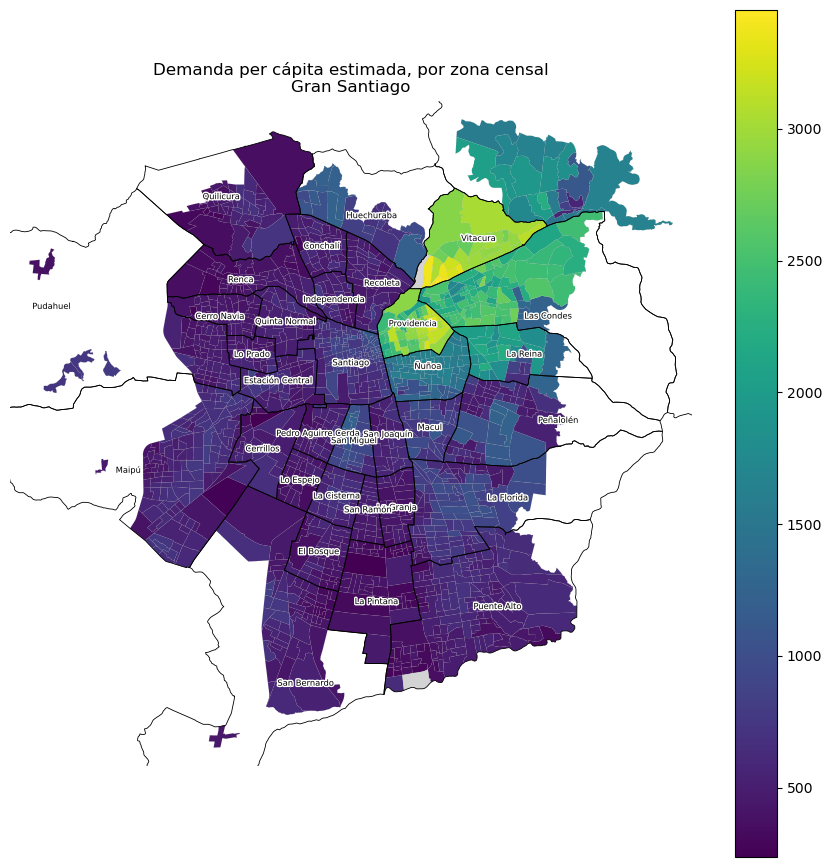

In [30]:
zonas_mapa = censo_zonal.set_index(ZONA_ID).join(resultados_zona[["demanda_percap"]])

fig, ax = plt.subplots(figsize=(11, 11))
zonas_mapa.plot(
    column="demanda_percap", cmap="viridis", linewidth=0.05, edgecolor="grey",
    legend=True, missing_kwds={"color": "lightgrey", "label": "sin dato"}, ax=ax,
)
censo_comunal.boundary.plot(ax=ax, color="black", linewidth=0.6)
for _, fila in censo_comunal.iterrows():
    punto = fila.geometry.representative_point()
    ax.annotate(
        fila["COMUNA"].title(), xy=(punto.x, punto.y), ha="center", va="center",
        fontsize=6, color="black", path_effects=[pe.withStroke(linewidth=2, foreground="white")],
    )

xmin, ymin, xmax, ymax = censo_zonal.total_bounds
mx, my = (xmax - xmin) * 0.03, (ymax - ymin) * 0.03
ax.set_xlim(xmin - mx, xmax + mx)
ax.set_ylim(ymin - my, ymax + my)
ax.set_title("Demanda per cápita estimada, por zona censal\nGran Santiago")
ax.set_axis_off()
plt.show()